CPI vs S&P 500 - Statistical Relationship Analysis

Goal: investigate whether Consumer Price Index (CPI) and Standard and Poor's 500 (S&P 500) performance are correlated.

Source of datasets: https://www.kaggle.com/datasets/rosicky1234/cpi-and-sp500$0
https://www.kaggle.com/datasets/tunguz/us-consumer-price-index-and-inflation-cpi$0
License - CC0: Public Domain Dedication and License v1.0
http://www.opendatacommons.org/licenses/pddl/1.0/


In [1]:
#import libraries
import pandas as pd
from scipy import stats
import numpy as np
import matplotlib.pyplot as plt


In [2]:
#import S&P 500 raw data
cols = ['date', 'open', 'close', 'high', 'low']
df_sp500 = pd.read_csv('SP500.csv', names = cols)

In [3]:
#check the file was imported with the right columns by looking at the first five rows
df_sp500.head()

,date,open,close,high,low
0,Date,open,high,low,close
1,1/3/2000,1469.25,1478.00,1438.36,1455.22
2,1/4/2000,1455.22,1455.22,1397.43,1399.42
3,1/5/2000,1399.42,1413.27,1377.68,1402.11
4,1/6/2000,1402.11,1411.90,1392.10,1403.45


In [4]:
df_sp500.drop(0, inplace = True)
df_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5821 entries, 1 to 5821
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   date    5821 non-null   object
 1   open    5821 non-null   object
 2   close   5821 non-null   object
 3   high    5821 non-null   object
 4   low     5821 non-null   object
dtypes: object(5)
memory usage: 227.5+ KB


In [5]:
df_sp500.head()

,date,open,close,high,low
1,1/3/2000,1469.25,1478.00,1438.36,1455.22
2,1/4/2000,1455.22,1455.22,1397.43,1399.42
3,1/5/2000,1399.42,1413.27,1377.68,1402.11
4,1/6/2000,1402.11,1411.90,1392.10,1403.45
5,1/7/2000,1403.45,1441.47,1400.73,1441.47


In [6]:
#load original CPI dataset
df_cpi = pd.read_csv ('CPI.csv')

In [7]:
df_cpi.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 130 entries, 0 to 129
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Year               130 non-null    int64  
 1   Month              130 non-null    int64  
 2   Day                130 non-null    int64  
 3   Actual             130 non-null    float64
 4   Predict            130 non-null    float64
 5   Previous           130 non-null    float64
 6   Diff_with_prev     130 non-null    float64
 7   Diff_with_predict  130 non-null    float64
dtypes: float64(5), int64(3)
memory usage: 8.3 KB


In [8]:
df_cpi.head()

,Year,Month,Day,Actual,Predict,Previous,Diff_with_prev,Diff_with_predict
0,2012,5,15,0.023,0.023,0.027,0.004,0.000
1,2012,6,14,0.017,0.018,0.023,0.006,-0.001
2,2012,7,17,0.017,0.016,0.017,0.000,0.001
3,2012,8,15,0.014,0.016,0.017,0.003,-0.002
4,2012,9,14,0.017,0.017,0.014,-0.003,0.000


This CPI dataset only has 130 data points, which is very limiting, so I found another dataset.

In [9]:
#load the alternative CPI dataset
df_cpi2 = pd.read_csv ('cpi_set2.csv')

In [10]:
df_cpi2.head()

,Date,Index,Inflation
0,1913-01-01,9.8,NaN
1,1913-02-01,9.8,0.00
2,1913-03-01,9.8,0.00
3,1913-04-01,9.8,0.00
4,1913-05-01,9.7,-1.02


However, there is a very important difference between the two CPI datasets. The first CPI dataset contains an 'Actual' column which represents the month-over-month % change in CPI which tells you how fast prices changed that month, which is not contained in the second CPI dataset. The second CPI dataset instead contains the actual CPI index level, which tells you the overall price level at that point. While these types of data are related, their scales and meanings are completely different.
So in this analysis, what I'm comparing is the CPI index leve against the S&P 500 closing price, which are both absolute levels and directly comparable.

In [11]:
df_cpi2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   Date       1213 non-null   object 
 1   Index      1213 non-null   float64
 2   Inflation  1212 non-null   float64
dtypes: float64(2), object(1)
memory usage: 28.6+ KB


The date datatype is an object, and it appears the format is year-month-day, which is different than the SP500 date, which is formatted as day/month/year. Must make the formats the same to be able to combine the datasets for analysis.

In [12]:
df_sp500["Date"] = pd.to_datetime(df_sp500['date'], format='mixed')
#used format = 'mixed' because upon checking the csv file, there were dates that used four digit years and some that used only two

In [13]:
df_sp500.head()

,date,open,close,high,low,Date
1,1/3/2000,1469.25,1478.00,1438.36,1455.22,2000-01-03
2,1/4/2000,1455.22,1455.22,1397.43,1399.42,2000-01-04
3,1/5/2000,1399.42,1413.27,1377.68,1402.11,2000-01-05
4,1/6/2000,1402.11,1411.90,1392.10,1403.45,2000-01-06
5,1/7/2000,1403.45,1441.47,1400.73,1441.47,2000-01-07


In [14]:
df_sp500.tail()

,date,open,close,high,low,Date
5817,02/14/2023,4126.70,4159.77,4095.01,4136.13,2023-02-14
5818,02/15/2023,4119.50,4148.11,4103.98,4147.60,2023-02-15
5819,02/16/2023,4114.75,4136.54,4089.49,4090.41,2023-02-16
5820,02/17/2023,4077.73,4081.51,4047.95,4079.09,2023-02-17
5821,02/21/2023,4052.35,4052.35,3995.19,3997.34,2023-02-21


In [15]:
df_cpi2["Date"] = pd.to_datetime (df_cpi2['Date'])

In [16]:
df_cpi2.head()

,Date,Index,Inflation
0,1913-01-01,9.8,NaN
1,1913-02-01,9.8,0.00
2,1913-03-01,9.8,0.00
3,1913-04-01,9.8,0.00
4,1913-05-01,9.7,-1.02


In [17]:
df_cpi2.tail()

,Date,Index,Inflation
1208,2013-09-01,234.149,0.12
1209,2013-10-01,233.546,-0.26
1210,2013-11-01,233.069,-0.20
1211,2013-12-01,233.049,-0.01
1212,2014-01-01,233.916,0.37


In [18]:
#checking on datatypes
df_cpi2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1213 entries, 0 to 1212
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       1213 non-null   datetime64[ns]
 1   Index      1213 non-null   float64       
 2   Inflation  1212 non-null   float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 28.6 KB


In [19]:
df_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5821 entries, 1 to 5821
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5821 non-null   object        
 1   open    5821 non-null   object        
 2   close   5821 non-null   object        
 3   high    5821 non-null   object        
 4   low     5821 non-null   object        
 5   Date    5821 non-null   datetime64[ns]
dtypes: datetime64[ns](1), object(5)
memory usage: 273.0+ KB


In [20]:
#issue with S&P500 dataset in that the open, close, high and low values are all in object formats when they should be float
for col in ['open', 'close', 'high', 'low']:
    df_sp500[col] = pd.to_numeric(df_sp500[col], errors='coerce')

The next problems with the imported datasets are:
1) S&P 500 is daily data, whereas CPI is monthly, we need to resample S&P data to monthly
2) They don't have the same date range. CPI data starts in 1913 and S&P500 starts in 2000.

In [21]:
df_sp500_monthly = df_sp500.set_index('Date').resample('ME').agg({
    'open': 'first',   # first open of the month
    'high': 'max',     # highest high of the month
    'low': 'min',      # lowest low of the month
    'close': 'last'    # last close of the month
}).reset_index()

In [22]:
df_sp500_monthly.head()

,Date,open,high,low,close
0,2000-01-31,1469.25,1451.30,1360.16,1394.48
1,2000-02-29,1394.46,1424.24,1333.36,1369.63
2,2000-03-31,1366.42,1518.46,1355.62,1519.81
3,2000-04-30,1498.58,1503.35,1356.56,1473.62
4,2000-05-31,1452.43,1452.43,1373.86,1434.49


In [23]:
df_sp500.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5821 entries, 1 to 5821
Data columns (total 6 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   date    5821 non-null   object        
 1   open    5821 non-null   float64       
 2   close   5821 non-null   float64       
 3   high    5821 non-null   float64       
 4   low     5821 non-null   float64       
 5   Date    5821 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(4), object(1)
memory usage: 273.0+ KB


In [24]:
df_cpi2_trimmed = df_cpi2[df_cpi2 ['Date'] >= '2000-01-01']

In [25]:
df_cpi2_trimmed.head()

,Date,Index,Inflation
1044,2000-01-01,168.8,0.30
1045,2000-02-01,169.8,0.59
1046,2000-03-01,171.2,0.82
1047,2000-04-01,171.3,0.06
1048,2000-05-01,171.5,0.12


In [26]:
df_cpi2_trimmed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 169 entries, 1044 to 1212
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       169 non-null    datetime64[ns]
 1   Index      169 non-null    float64       
 2   Inflation  169 non-null    float64       
dtypes: datetime64[ns](1), float64(2)
memory usage: 5.3 KB


After trimming this new CPI dataset to start from the year 2000, to match up with the S&P500 dataset, there's only an extra 39 data points, which is not much of an improvement from the old CPI dataset.

In [27]:
#since the S&P500 data is indexed by the date at the end of the month and CPI is at the beginning of the month, I need to normalie both to month-start for merging


print(df_sp500_monthly.index)
print(df_sp500_monthly.columns)

df_sp500_monthly['Date'] = df_sp500_monthly['Date'].dt.to_period('M').dt.to_timestamp()
print(df_sp500_monthly['Date'].head())

RangeIndex(start=0, stop=278, step=1)
Index(['Date', 'open', 'high', 'low', 'close'], dtype='object')
0   2000-01-01
1   2000-02-01
2   2000-03-01
3   2000-04-01
4   2000-05-01
Name: Date, dtype: datetime64[ns]


In [28]:
print(df_cpi2_trimmed.columns)
print(df_cpi2_trimmed.index)

Index(['Date', 'Index', 'Inflation'], dtype='object')
Index([1044, 1045, 1046, 1047, 1048, 1049, 1050, 1051, 1052, 1053,
       ...
       1203, 1204, 1205, 1206, 1207, 1208, 1209, 1210, 1211, 1212],
      dtype='int64', length=169)


In [29]:
df_cpi2_new = df_cpi2_trimmed.reset_index(drop=True)
df_cpi2_new['Date'] = df_cpi2_new['Date'].dt.to_period('M').dt.to_timestamp()

In [30]:
#check cpi and sp500 indexes

print(df_cpi2_new.index)

RangeIndex(start=0, stop=169, step=1)


In [31]:
print(df_sp500_monthly.index)

RangeIndex(start=0, stop=278, step=1)


In [32]:
#time to merge the datasets for analysis
df_merged = pd.merge(df_sp500_monthly, df_cpi2_new, on='Date', how='inner')
print(df_merged.shape)

(169, 7)


In [33]:
df_merged.head()

,Date,open,high,low,close,Index,Inflation
0,2000-01-01,1469.25,1451.30,1360.16,1394.48,168.8,0.30
1,2000-02-01,1394.46,1424.24,1333.36,1369.63,169.8,0.59
2,2000-03-01,1366.42,1518.46,1355.62,1519.81,171.2,0.82
3,2000-04-01,1498.58,1503.35,1356.56,1473.62,171.3,0.06
4,2000-05-01,1452.43,1452.43,1373.86,1434.49,171.5,0.12


In [34]:
df_merged.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 169 entries, 0 to 168
Data columns (total 7 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   Date       169 non-null    datetime64[ns]
 1   open       169 non-null    float64       
 2   high       169 non-null    float64       
 3   low        169 non-null    float64       
 4   close      169 non-null    float64       
 5   Index      169 non-null    float64       
 6   Inflation  169 non-null    float64       
dtypes: datetime64[ns](1), float64(6)
memory usage: 9.4 KB


In [35]:
df_merged.shape

(169, 7)

In [36]:
df_merged.head()

,Date,open,high,low,close,Index,Inflation
0,2000-01-01,1469.25,1451.30,1360.16,1394.48,168.8,0.30
1,2000-02-01,1394.46,1424.24,1333.36,1369.63,169.8,0.59
2,2000-03-01,1366.42,1518.46,1355.62,1519.81,171.2,0.82
3,2000-04-01,1498.58,1503.35,1356.56,1473.62,171.3,0.06
4,2000-05-01,1452.43,1452.43,1373.86,1434.49,171.5,0.12


In [37]:
# I don't want all the columns from CPI in my merged dataset. I just want 'Index' and to rename it 'CPI'
df_merged.rename(columns={'Index': 'CPI'}, inplace=True)
df_merged = df_merged[['Date', 'open', 'high', 'low', 'close', 'CPI']]
print(df_merged.shape)
print(df_merged.head())

(169, 6)
        Date     open     high      low    close    CPI
0 2000-01-01  1469.25  1451.30  1360.16  1394.48  168.8
1 2000-02-01  1394.46  1424.24  1333.36  1369.63  169.8
2 2000-03-01  1366.42  1518.46  1355.62  1519.81  171.2
3 2000-04-01  1498.58  1503.35  1356.56  1473.62  171.3
4 2000-05-01  1452.43  1452.43  1373.86  1434.49  171.5


In [38]:
df_merged.head()

,Date,open,high,low,close,CPI
0,2000-01-01,1469.25,1451.30,1360.16,1394.48,168.8
1,2000-02-01,1394.46,1424.24,1333.36,1369.63,169.8
2,2000-03-01,1366.42,1518.46,1355.62,1519.81,171.2
3,2000-04-01,1498.58,1503.35,1356.56,1473.62,171.3
4,2000-05-01,1452.43,1452.43,1373.86,1434.49,171.5


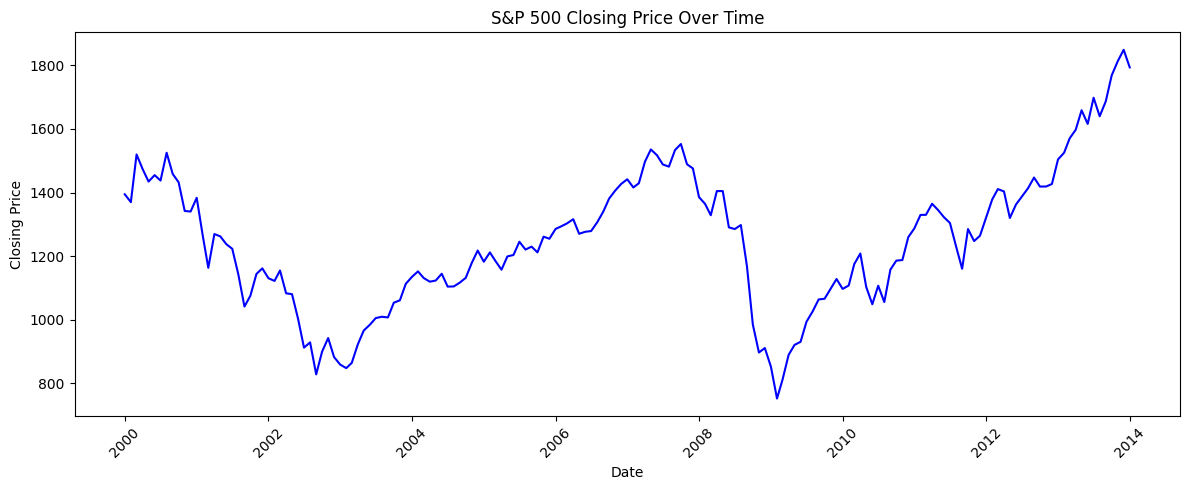

In [39]:
#Visualizations:
## S&P 500 closing price over time - line plot of close vs Date

#make sure values are numeric so they can be plotted
df_merged['close'] = pd.to_numeric(df_merged['close'])
df_merged['open'] = pd.to_numeric(df_merged['open'])
df_merged['high'] = pd.to_numeric(df_merged['high'])
df_merged['low'] = pd.to_numeric(df_merged['low'])

#sort by date to make sure the line plots correctly
df_merged = df_merged.sort_values('Date').reset_index(drop=True)

plt.figure(figsize=(12, 5))
plt.plot(df_merged['Date'], df_merged['close'], color='blue')
plt.title('S&P 500 Closing Price Over Time')
plt.xlabel('Date')
plt.ylabel('Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

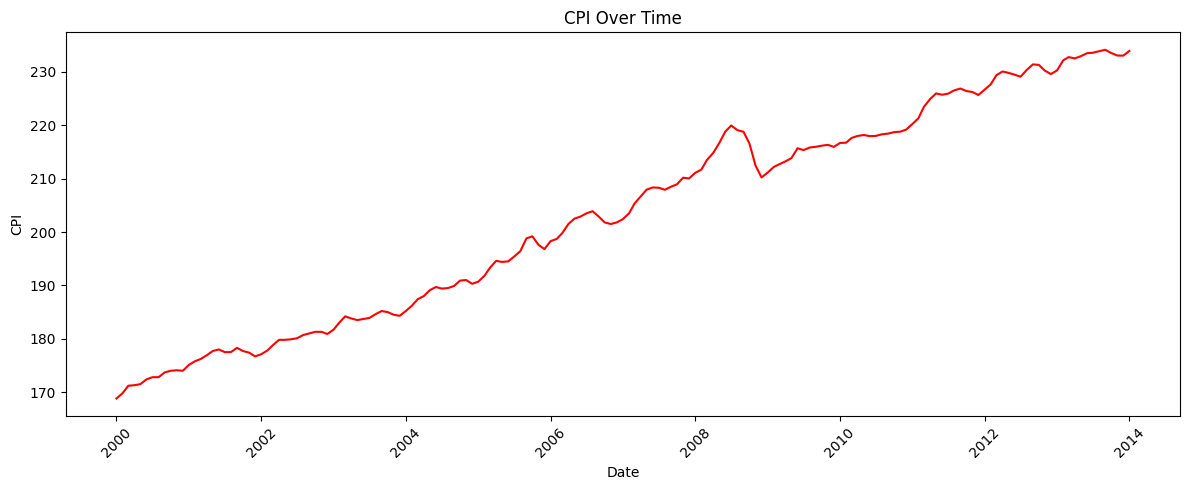

In [40]:
#Visualization: CPI over time

plt.figure(figsize=(12,5))
plt.plot (df_merged['Date'], df_merged['CPI'], color = 'red')
plt.title ('CPI Over Time')
plt.xlabel ('Date')
plt.ylabel ('CPI')
plt.xticks (rotation = 45)
plt.tight_layout()
plt.show()

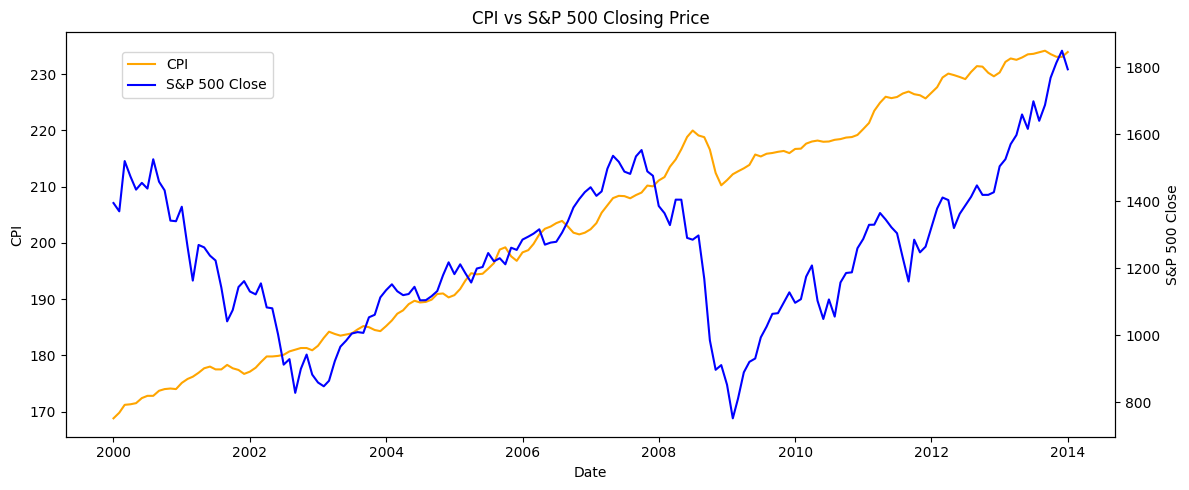

In [41]:
#overlap the visualizations to compare them

fig, ax1 = plt.subplots(figsize=(12, 5))

ax1.plot(df_merged['Date'], df_merged['CPI'], label='CPI', color='orange')
ax1.set_xlabel('Date')
ax1.set_ylabel('CPI')

ax2 = ax1.twinx()
ax2.plot(df_merged['Date'], df_merged['close'], label='S&P 500 Close', color='blue')
ax2.set_ylabel('S&P 500 Close')

fig.legend(loc='upper left', bbox_to_anchor=(0.1, 0.9))
plt.title('CPI vs S&P 500 Closing Price')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Just by the visualization, it does not appear that these two time series data have a similar trend. CPI trends linearly upwards over the years while S&P500 goes down between 2000 and 2003, then rises from 2003 to 2008, then falls between 2008 and 2009, rising from 2009 to 2010.

In [42]:
#Check for correlation:
##pearson r

from scipy.stats import pearsonr

correlation, pvalue = pearsonr(df_merged['CPI'], df_merged['close'])
print(f'Pearson correlation coefficient: {correlation:.4f}')
print(f'P-value: {pvalue:.4f}')
print(f'Statistically significant: {pvalue < 0.05}')

Pearson correlation coefficient: 0.3817
P-value: 0.0000
Statistically significant: True


I wonder what kind of result I would get if I were to compare the inflation rate from CPI_set2 and compare it to the S&P500 closing prices instead.

In [43]:
#derive inflation rate from cpi_set2.csv, which would make it comparable to my analysis using the first CPI set but with more data points

In [44]:
df_cpi2_new['inflation_rate'] = df_cpi2_new['Index'].pct_change()
df_cpi2_new = df_cpi2_new.dropna(subset=['inflation_rate']).reset_index(drop=True)

In [45]:
df_cpi2_new.head()

,Date,Index,Inflation,inflation_rate
0,2000-02-01,169.8,0.59,0.005924
1,2000-03-01,171.2,0.82,0.008245
2,2000-04-01,171.3,0.06,0.000584
3,2000-05-01,171.5,0.12,0.001168
4,2000-06-01,172.4,0.52,0.005248


In [46]:
has_nan = df_cpi2_new.isnull().values.any()
print(f'DataFrame contains NaN values: {has_nan}')

DataFrame contains NaN values: False


In [47]:
# 1. Merge inflation_rate with S&P 500
df_merged2 = pd.merge(df_sp500_monthly, df_cpi2_new[['Date', 'inflation_rate']], on='Date', how='inner')


In [48]:
# 2. Pearson correlation — inflation rate vs S&P 500 close
corr2, pval2 = pearsonr(df_merged2['inflation_rate'], df_merged2['close'])
print(f'Pearson r (inflation rate vs close): {corr2:.4f}, p-value: {pval2:.4f}')
print(f'Statistically significant: {pval2 < 0.05}')

Pearson r (inflation rate vs close): 0.1097, p-value: 0.1568
Statistically significant: False


In [49]:
# 3. Compare results
print(f'CPI level vs S&P 500:    r = 0.3817')
print(f'Inflation rate vs S&P 500: r = {corr2:.4f}')

CPI level vs S&P 500:    r = 0.3817
Inflation rate vs S&P 500: r = 0.1097


Comparison


*   CPI level vs S&P 500 close, r = 0.3817, p-value = 0.0000, significant? Yes
*   Inflation rate vs S&P 500 close, r =0.1097, p-value = 0.1568, significant? No

The price level has a weak but real correlation with S&P 500, but the month-to-month rate of change in prices has no statistically significant relationship with S&P 500 levels.



Since there's a positive correlation between CPI level and S&p 500 closing prices, and it's statistically significant at the 0.05 level, I want to use the Granger Causality test to check whether CPI can predict S&P 500 or vice versa.



In [51]:
'''Check for stationarity first
Why? the Granger Causality Test assumes both time series are stationary - meaning their
mean and variance don't change over time.
If the data is non-stationary, the test results can be spurious, meaning it might show a relationship
between the two variables even when there isn't one. This is a common issue with financial and economic time series like
S&P 500 and CPI, which tend to trend upward over time.
The Augmented Dickey-Fuller (ADF) test can be used to check for stationarity.
'''

from statsmodels.tsa.stattools import adfuller

def adf_test(series):
  res = adfuller (series, autolag = 'AIC')
  if res [1] < 0.05:
    print ('Stationary')
  else:
    print ('Non-stationary')

In [52]:
adf_test (df_merged ['close'])
adf_test (df_merged ['CPI'])

Non-stationary
Non-stationary


In [53]:
'''The p-values for both datasets is above 0.05 indicating they're non-stationary
A possible fix is to difference the data (subtract each value from the previous one), which removes the trend:
'''

df_merged['close_diff'] = df_merged['close'].diff()
df_merged['CPI_diff'] = df_merged['CPI'].diff()

In [54]:
#Complete an adf test on the new values
##drop na had to be used because the first row has no previous value to subtract from, so it becomes NaN which the ADF test can't handle

adf_test (df_merged['close_diff'].dropna())
adf_test (df_merged['CPI_diff'].dropna())

Stationary
Stationary


In [56]:
#rename the datasets to make it easier to refer to them in the test

SP_diff = df_merged['close_diff'].dropna()
CPI_diff = df_merged['CPI_diff'].dropna()


In [57]:
SP_diff.head()

,close_diff
1,-24.85
2,150.18
3,-46.19
4,-39.13
5,20.19


In [58]:
CPI_diff.head()

,CPI_diff
1,1.0
2,1.4
3,0.1
4,0.2
5,0.9


Now that both are stationary, it's time to complete the Granger Causality test

In [59]:
from statsmodels.tsa.stattools import grangercausalitytests

In [61]:
max_lag = 4
data = pd.concat ([SP_diff, CPI_diff], axis = 1).dropna()

Granger Causality Test 1: Does CPI Granger-cause S&P 500?

In [62]:
results = grangercausalitytests(data[['close_diff', 'CPI_diff']], max_lag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=0.3817  , p=0.5376  , df_denom=164, df_num=1
ssr based chi2 test:   chi2=0.3887  , p=0.5330  , df=1
likelihood ratio test: chi2=0.3882  , p=0.5332  , df=1
parameter F test:         F=0.3817  , p=0.5376  , df_denom=164, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=0.1762  , p=0.8386  , df_denom=161, df_num=2
ssr based chi2 test:   chi2=0.3634  , p=0.8338  , df=2
likelihood ratio test: chi2=0.3630  , p=0.8340  , df=2
parameter F test:         F=0.1762  , p=0.8386  , df_denom=161, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=0.0942  , p=0.9631  , df_denom=158, df_num=3
ssr based chi2 test:   chi2=0.2952  , p=0.9609  , df=3
likelihood ratio test: chi2=0.2949  , p=0.9610  , df=3
parameter F test:         F=0.0942  , p=0.9631  , df_denom=158, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=1.8138  , p=0.1289  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Results: Throughout all lags, the p-values are always above 0.05.
Conclusion: CPI does not strongly Granger-cause S&P500

Granger Causality Test 2: Does S&P 500 Granger-cause CPI?

In [63]:
#reverse the order
results2 = grangercausalitytests(data[['CPI_diff', 'close_diff']], max_lag, verbose=True)


Granger Causality
number of lags (no zero) 1
ssr based F test:         F=9.3358  , p=0.0026  , df_denom=164, df_num=1
ssr based chi2 test:   chi2=9.5066  , p=0.0020  , df=1
likelihood ratio test: chi2=9.2459  , p=0.0024  , df=1
parameter F test:         F=9.3358  , p=0.0026  , df_denom=164, df_num=1

Granger Causality
number of lags (no zero) 2
ssr based F test:         F=5.6879  , p=0.0041  , df_denom=161, df_num=2
ssr based chi2 test:   chi2=11.7291 , p=0.0028  , df=2
likelihood ratio test: chi2=11.3332 , p=0.0035  , df=2
parameter F test:         F=5.6879  , p=0.0041  , df_denom=161, df_num=2

Granger Causality
number of lags (no zero) 3
ssr based F test:         F=4.6647  , p=0.0038  , df_denom=158, df_num=3
ssr based chi2 test:   chi2=14.6140 , p=0.0022  , df=3
likelihood ratio test: chi2=14.0027 , p=0.0029  , df=3
parameter F test:         F=4.6647  , p=0.0038  , df_denom=158, df_num=3

Granger Causality
number of lags (no zero) 4
ssr based F test:         F=3.4902  , p=0.0093  

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning: verbose is deprecated since functions should not print results
  warnings.warn(


Results: All lags show p-values below 0.05.
Conclusion: S&P 500 does Granger-cause CPI -- past stock mark movements have statistically predictive power over future CPI changes.

## **Overall Takeaways:**

The analysis reveals a positive correlation between the S&P 500 and CPI. Furthermore, the Granger causality test suggests this relationship is one-directional — past stock market movements appear to predict future changes in inflation, but not vice versa.

Notes:
* Granger causality does not imply true economic causality — it only indicates predictive power within this statistical framework.
* And S&P 500 past values help predict CPI better than CPI's own past values alone, but Granger causality is not true causality.

## **Limitations**
* Only 169 months of overlapping data
(2000–2014)
* Pearson correlation assumes a linear relationship — the CPI vs S&P 500 relationship may not be linear
* The inner join silently drops months where one dataset had no data
* External confounders (interest rates, GDP, global events) not accounted for